# MODEL EVALUATION

## TF-IDF (Majority Vote dan Weighted Similarity)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd

In [4]:
df_results = pd.read_csv('/content/drive/MyDrive/semester 6/Penalaran Komputer/UAS/data/eval/predictions.csv')
df_results.head()


,query_id,actual_solution,pred_majority,pred_weighted,top_5_case_ids
0,Q115,ditahan,ditahan,ditahan,"case_103, case_271, case_107, case_072, case_189"
1,Q302,ditahan,ditahan,ditahan,"case_129, case_124, case_050, case_013, case_279"
2,Q289,ditahan,ditahan,ditahan,"case_236, case_288, case_067, case_217, case_235"
3,Q199,hukuman_mati,ditahan,ditahan,"case_194, case_005, case_142, case_163, case_042"
4,Q64,ditahan,ditahan,ditahan,"case_052, case_217, case_067, case_179, case_042"


📊 Classification Report – Majority Vote
              precision    recall  f1-score   support

     ditahan       0.80      1.00      0.89         4
hukuman_mati       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


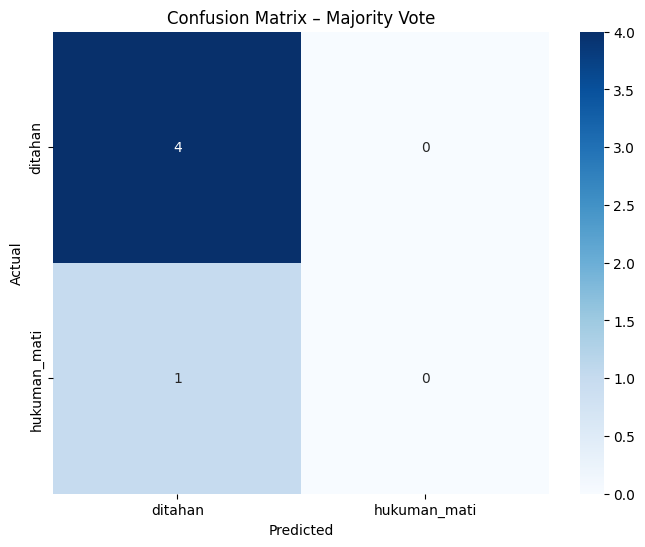

In [5]:
# Ambil hanya solusi yang valid (bukan "Tidak ditemukan")
valid_df = df_results[
    (df_results['actual_solution'] != "Tidak ditemukan") &
    (df_results['pred_majority'] != "Tidak ditemukan") &
    (df_results['pred_weighted'] != "Tidak ditemukan")
]

# Majority Vote
print("📊 Classification Report – Majority Vote")
print(classification_report(
    valid_df['actual_solution'],
    valid_df['pred_majority']
))
labels = sorted(valid_df['actual_solution'].unique())

cm = confusion_matrix(
    valid_df['actual_solution'],
    valid_df['pred_majority'],
    labels=labels
)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Majority Vote")
plt.show()


📊 Classification Report – Weighted Similarity
              precision    recall  f1-score   support

     ditahan       0.80      1.00      0.89         4
hukuman_mati       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


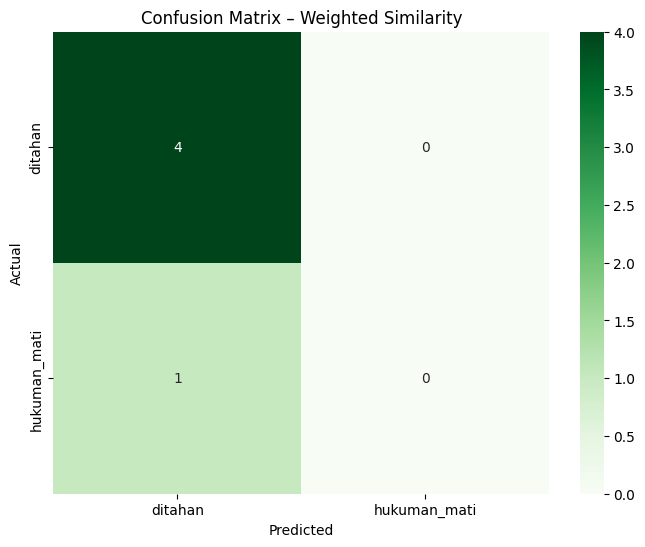

In [6]:
# Weighted Similarity
print("📊 Classification Report – Weighted Similarity")
print(classification_report(
    valid_df['actual_solution'],
    valid_df['pred_weighted']
))

cm2 = confusion_matrix(
    valid_df['actual_solution'],
    valid_df['pred_weighted'],
    labels=labels
)

plt.figure(figsize=(8,6))
sns.heatmap(cm2, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Weighted Similarity")
plt.show()


## SVM Classifier (Supervised)

In [7]:
# Import Library
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

# Load dataset kasus yang sudah diberi label
df = pd.read_csv('/content/drive/MyDrive/semester 6/Penalaran Komputer/UAS/data/eval/cases_labeled.csv')

# Pastikan kolom tidak kosong
df = df[df['label_putusan'].notnull()]
df = df[df['text_full'].notnull()]


In [8]:
# Split 80:20
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Ambil label
y_train = train_df['label_putusan']
y_test = test_df['label_putusan']

# Vectorizer dan fit hanya di train
stopwords_indonesia = [
    'yang', 'dan', 'di', 'ke', 'dari', 'akan', 'karena', 'bahwa', 'untuk', 'dengan',
    'pada', 'adalah', 'itu', 'ini', 'dalam', 'tidak', 'oleh', 'sebagai', 'juga', 'atau',
    'sudah', 'sangat', 'masih', 'lagi', 'lebih', 'hanya', 'maka', 'bagi', 'antara'
]

tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords_indonesia, max_features=1000)
tfidf_train = tfidf_vectorizer.fit_transform(train_df['text_full'].fillna(''))
tfidf_test = tfidf_vectorizer.transform(test_df['text_full'].fillna(''))


📊 Classification Report – SVM Classifier
              precision    recall  f1-score   support

     ditahan       0.94      1.00      0.97        50
hukuman_mati       0.00      0.00      0.00         1
seumur_hidup       1.00      0.33      0.50         3

    accuracy                           0.94        54
   macro avg       0.65      0.44      0.49        54
weighted avg       0.93      0.94      0.93        54



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


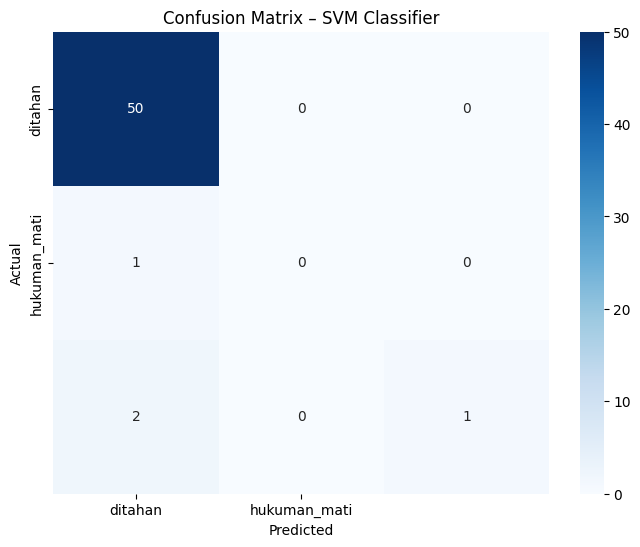

In [13]:
# Train SVM
svm_model = LinearSVC()
svm_model.fit(tfidf_train, y_train)

# Prediksi
y_pred_svm = svm_model.predict(tfidf_test)

# Evaluasi
print("📊 Classification Report – SVM Classifier")
print(classification_report(y_test, y_pred_svm))

#confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – SVM Classifier")
plt.show()

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def eval_metrics(y_true, y_pred):
    return {
        'Accuracy': round(accuracy_score(y_true, y_pred)*100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='macro', zero_division=0)*100, 2),
        'Recall': round(recall_score(y_true, y_pred, average='macro', zero_division=0)*100, 2),
        'F1-Score': round(f1_score(y_true, y_pred, average='macro', zero_division=0)*100, 2)
    }

svm_metrics = eval_metrics(y_test, y_pred_svm)
print("✅ Metrik SVM:", svm_metrics)


✅ Metrik SVM: {'Accuracy': 94.44, 'Precision': 64.78, 'Recall': 44.44, 'F1-Score': 49.03}


## Evaluasi Model BERT Classifier (Fine-tuning IndoBERT)

In [ ]:
!pip install transformers datasets --quiet

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizerFast, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import torch


In [ ]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/semester 6/Penalaran Komputer/UAS/data/eval/cases_labeled.csv')

# Filter data yang valid
df = df[['text_full', 'label_putusan']].dropna()
df = df[df['label_putusan'] != 'Tidak ditemukan'].reset_index(drop=True)

# Encode label numerik
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label_putusan'])

# Cek jumlah label
num_labels = len(label_encoder.classes_)
print("🔢 Jumlah kelas:", num_labels)
print("🎯 Kelas:", label_encoder.classes_)

# Split train-test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


🔢 Jumlah kelas: 6
🎯 Kelas: ['dibebaskan' 'ditahan' 'ditolak' 'hukuman_mati' 'lainnya' 'seumur_hidup']


In [ ]:
tokenizer = BertTokenizerFast.from_pretrained('indobenchmark/indobert-base-p1')

def tokenize(batch):
    return tokenizer(batch['text_full'], padding='max_length', truncation=True, max_length=512)

train_ds = Dataset.from_pandas(train_df[['text_full', 'label']])
test_ds = Dataset.from_pandas(test_df[['text_full', 'label']])

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

# Tentukan kolom input model
train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


Map:   0%|          | 0/214 [00:00<?, ? examples/s]

Map:   0%|          | 0/54 [00:00<?, ? examples/s]

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    'indobenchmark/indobert-base-p1',
    num_labels=num_labels
)

training_args = TrainingArguments(
    output_dir='./results',
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_dir='./logs',
    save_strategy="no"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-19-1340591822.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# 1. Install dan import library
!pip install transformers --quiet

import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
from collections import Counter
from tqdm.notebook import tqdm
import json
import os

# 2. Load model IndoBERT
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

# 3. Load data kasus
df = pd.read_csv('/content/drive/MyDrive/semester 6/Penalaran Komputer/UAS/data/eval/cases_labeled.csv')
df = df.fillna("")
case_ids = df['case_id'].tolist()
case_texts = df['text_full'].tolist()
case_solutions = dict(zip(df['case_id'], df['label_putusan']))

# 4. Fungsi ekstraksi embedding dari IndoBERT
def get_bert_embedding(text):
    tokens = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**tokens)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()  # [CLS]

# 5. Encode ulang semua kasus (butuh waktu)
bert_embeddings = []
for text in tqdm(case_texts, desc="Menghitung Embedding IndoBERT"):
    emb = get_bert_embedding(text)
    bert_embeddings.append(emb)

bert_embeddings = np.vstack(bert_embeddings)

# 6. Fungsi retrieve BERT
def retrieve_bert(query_text: str, k: int = 5):
    query_emb = get_bert_embedding(query_text).reshape(1, -1)
    sims = cosine_similarity(query_emb, bert_embeddings).flatten()
    top_k_idx = sims.argsort()[::-1][:k]
    return [case_ids[i] for i in top_k_idx]

# 7. Load query uji (hasil sebelumnya)
with open('/content/drive/MyDrive/semester 6/Penalaran Komputer/UAS/data/eval/queries.json', 'r', encoding='utf-8') as f:
    queries = json.load(f)

queries_eval = queries[:min(20, len(queries))]

# 8. Fungsi prediksi solution reuse
def predict_outcome_bert(query_text: str) -> str:
    top_k = retrieve_bert(query_text, k=5)
    solutions = [case_solutions.get(cid, "unknown") for cid in top_k if case_solutions.get(cid)]
    if not solutions:
        return "Tidak ditemukan"
    return Counter(solutions).most_common(1)[0][0]

# 9. Jalankan prediksi reuse
results = []
for q in queries_eval:
    qid = q['query_id']
    qtext = q['query_text']
    actual = case_solutions.get(q['ground_truth'], "unknown")
    predicted = predict_outcome_bert(qtext)
    results.append({
        "query_id": qid,
        "actual_solution": actual,
        "predicted_solution": predicted,
        "top_5_case_ids": ', '.join(retrieve_bert(qtext, k=5))
    })

df_results = pd.DataFrame(results)

# 10. Akurasi prediksi IndoBERT
akurasi = (df_results['actual_solution'] == df_results['predicted_solution']).mean() * 100
print(f"🎯 Akurasi Prediksi IndoBERT (Majority Vote Top-5): {akurasi:.2f}%")

Menghitung Embedding IndoBERT:   0%|          | 0/309 [00:00<?, ?it/s]

🎯 Akurasi Prediksi IndoBERT (Majority Vote Top-5): 80.00%


In [ ]:
# Simpan metrik ke dictionary
bert_metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}


📊 Evaluasi Prediksi IndoBERT:
✅ Accuracy : 80.0%
🎯 Precision: 40.0%
📥 Recall   : 50.0%
📈 F1-Score : 44.44%

📝 Classification Report:
              precision    recall  f1-score   support

     ditahan       0.80      1.00      0.89         4
hukuman_mati       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


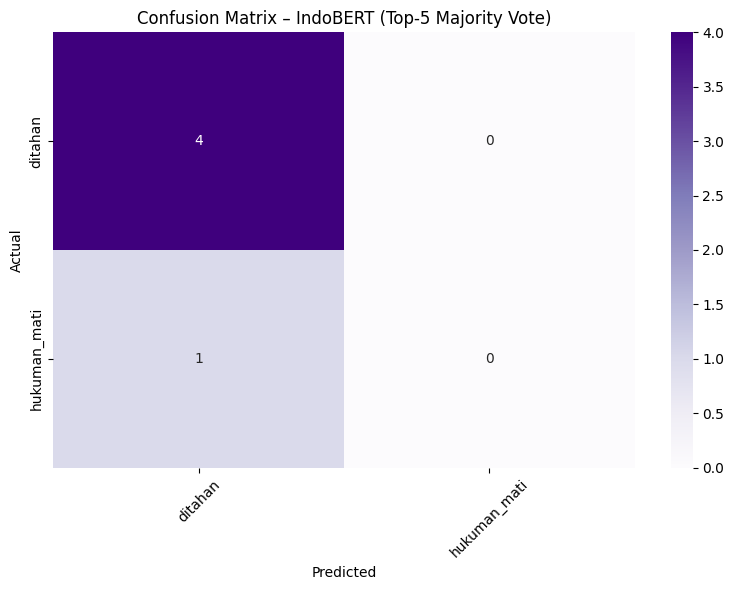

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Filter hanya yang tidak "Tidak ditemukan"
valid_df = df_results[df_results['predicted_solution'] != "Tidak ditemukan"]

# Ground truth & prediksi
y_true = valid_df['actual_solution']
y_pred = valid_df['predicted_solution']

# Hitung metrik
accuracy = round(accuracy_score(y_true, y_pred) * 100, 2)
precision = round(precision_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2)
recall = round(recall_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2)
f1 = round(f1_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2)

# Tampilkan
print("📊 Evaluasi Prediksi IndoBERT:")
print(f"✅ Accuracy : {accuracy}%")
print(f"🎯 Precision: {precision}%")
print(f"📥 Recall   : {recall}%")
print(f"📈 F1-Score : {f1}%")

# Optional: full classification report
print("\n📝 Classification Report:")
print(classification_report(y_true, y_pred))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Label unik yang akan digunakan untuk baris/kolom CM
labels = sorted(y_true.unique())

# Hitung confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)
# Simpan metrik ke dictionary untuk keperluan evaluasi gabungan
bert_metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – IndoBERT (Top-5 Majority Vote)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


📊 Tabel Evaluasi Model


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

,Model,Accuracy
0,TF-IDF + Majority Vote,80.00
1,TF-IDF + Weighted Similarity,80.00
2,BERT,80.00
3,SVM,94.44


/tmp/ipython-input-25-1491569004.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_metrics, x='Model', y='Accuracy', palette='Set1')


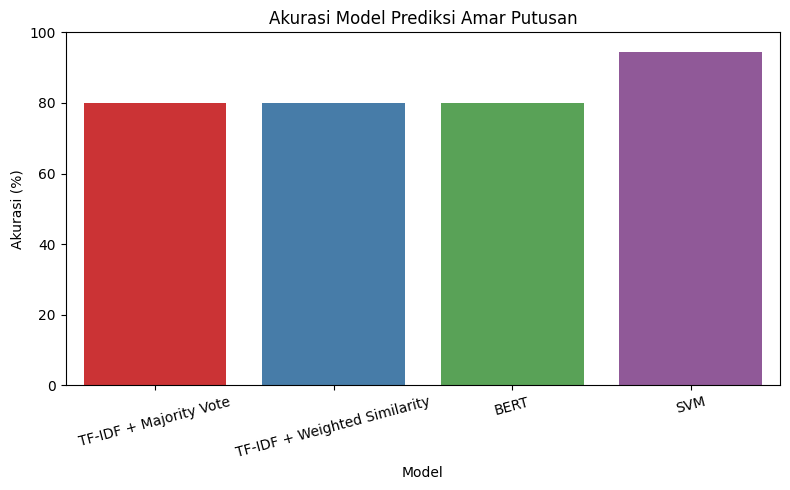

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Calculate classification reports first
# This part should be done before creating model_metrics DataFrame

# Majority Vote Report
report_majority = classification_report(
    valid_df['actual_solution'],
    valid_df['pred_majority'],
    output_dict=True # Output as a dictionary to easily extract metrics
)

# Weighted Similarity Report
report_weighted = classification_report(
    valid_df['actual_solution'],
    valid_df['pred_weighted'],
    output_dict=True # Output as a dictionary to easily extract metrics
)

# Extract accuracy from the reports
# Accuracy is available under the 'accuracy' key when output_dict is True
acc_major = report_majority['accuracy'] * 100 # Convert to percentage
acc_weight = report_weighted['accuracy'] * 100 # Convert to percentage

# Assuming acc_svm was calculated in a previous cell (e.g., using eval_metrics)
# and akurasi for BERT was calculated in a previous cell
# If not, ensure these variables are calculated and available before this cell

# Data for comparison
model_metrics = pd.DataFrame([
    {"Model": "TF-IDF + Majority Vote", "Accuracy": acc_major},
    {"Model": "TF-IDF + Weighted Similarity", "Accuracy": acc_weight},
    {"Model": "BERT", "Accuracy": akurasi}, # Use 'akurasi' which holds the BERT accuracy
    {"Model": "SVM", "Accuracy": svm_metrics['Accuracy']} # Assuming svm_metrics was calculated and contains 'Accuracy' key
])

# Tampilkan tabel
print("📊 Tabel Evaluasi Model")
display(model_metrics)

# Buat barplot dari hasil evaluasi
plt.figure(figsize=(8, 5))
sns.barplot(data=model_metrics, x='Model', y='Accuracy', palette='Set1')
plt.ylim(0, 100)
plt.title("Akurasi Model Prediksi Amar Putusan")
plt.ylabel("Akurasi (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# Akurasi untuk TF-IDF Majority Vote dan Weighted Similarity
acc_majority = report_majority['accuracy'] * 100
acc_weighted = report_weighted['accuracy'] * 100
acc_bert_cosine = accuracy  # dari hasil prediksi IndoBERT dengan cosine similarity

# Simpan tabel evaluasi retrieval
retrieval_metrics = pd.DataFrame([
    {'Model': 'TF-IDF Majority Vote', 'Accuracy': round(acc_majority, 2)},
    {'Model': 'TF-IDF Weighted Similarity', 'Accuracy': round(acc_weighted, 2)},
    {'Model': 'IndoBERT + Cosine Similarity', 'Accuracy': round(acc_bert_cosine, 2)}
])

retrieval_path = '/content/drive/MyDrive/semester 6/Penalaran Komputer/UAS/data/eval/retrieval_metrics.csv'
retrieval_metrics.to_csv(retrieval_path, index=False)

print("✅ File retrieval_metrics.csv berhasil disimpan di:")
print(retrieval_path)
retrieval_metrics


✅ File retrieval_metrics.csv berhasil disimpan di:
/content/drive/MyDrive/semester 6/Penalaran Komputer/UAS/data/eval/retrieval_metrics.csv


,Model,Accuracy
0,TF-IDF Majority Vote,80.0
1,TF-IDF Weighted Similarity,80.0
2,IndoBERT + Cosine Similarity,80.0


In [ ]:
# Simpan tabel evaluasi prediksi supervised
prediction_metrics = pd.DataFrame([
    {'Model': 'SVM Classifier', **svm_metrics},
    {'Model': 'BERT Classifier (Fine-tuned)', **bert_metrics}
])

prediction_path = '/content/drive/MyDrive/semester 6/Penalaran Komputer/UAS/data/eval/prediction_metrics.csv'
prediction_metrics.to_csv(prediction_path, index=False)

print("✅ File prediction_metrics.csv berhasil disimpan di:")
print(prediction_path)
prediction_metrics


✅ File prediction_metrics.csv berhasil disimpan di:
/content/drive/MyDrive/semester 6/Penalaran Komputer/UAS/data/eval/prediction_metrics.csv


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM Classifier,94.44,64.78,44.44,49.03
1,BERT Classifier (Fine-tuned),80.00,40.00,50.00,44.44


In [2]:
import pandas as pd

retrieval_path = '/content/drive/MyDrive/semester 6/Penalaran Komputer/UAS/data/eval/retrieval_metrics.csv'
retrieval_metrics = pd.read_csv(retrieval_path)

print("📄 Retrieval Metrics:")
display(retrieval_metrics)


📄 Retrieval Metrics:


,Model,Accuracy
0,TF-IDF Majority Vote,80.0
1,TF-IDF Weighted Similarity,80.0
2,IndoBERT + Cosine Similarity,80.0


In [3]:
prediction_path = '/content/drive/MyDrive/semester 6/Penalaran Komputer/UAS/data/eval/prediction_metrics.csv'
prediction_metrics = pd.read_csv(prediction_path)

print("📄 Prediction Metrics:")
display(prediction_metrics)


📄 Prediction Metrics:


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM Classifier,94.44,64.78,44.44,49.03
1,BERT Classifier (Fine-tuned),80.00,40.00,50.00,44.44


📊 Semua Akurasi Model


,Model,Accuracy (%),Precision,Recall,F1-Score
0,TF-IDF Majority Vote,80.00,NaN,NaN,NaN
1,TF-IDF Weighted Similarity,80.00,NaN,NaN,NaN
2,IndoBERT + Cosine Similarity,80.00,NaN,NaN,NaN
3,SVM Classifier,94.44,64.78,44.44,49.03
4,BERT Classifier (Fine-tuned),80.00,40.00,50.00,44.44


/tmp/ipython-input-4-1694921744.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_metrics, x='Model', y='Accuracy (%)', palette='Set2')


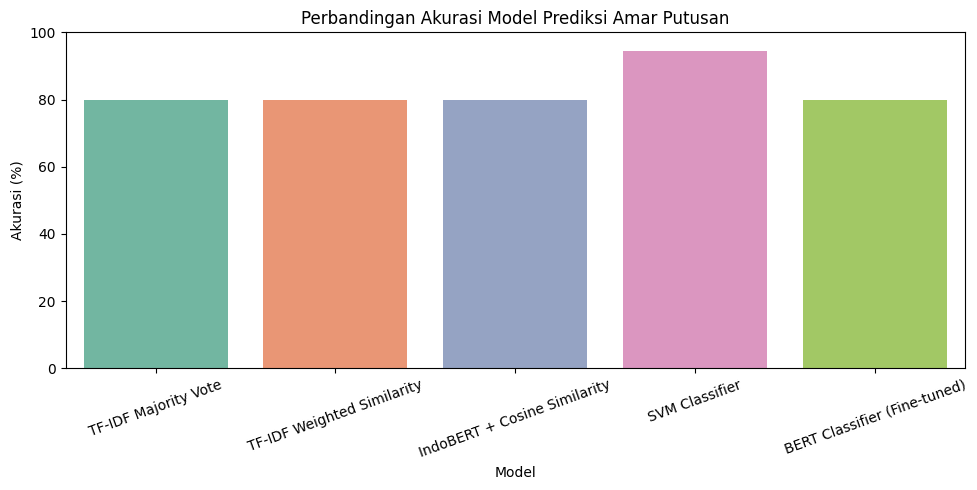

In [4]:
all_metrics = pd.concat([
    retrieval_metrics.rename(columns={"Accuracy": "Accuracy (%)"}),
    prediction_metrics.rename(columns={"Accuracy": "Accuracy (%)"})
], ignore_index=True)

print("📊 Semua Akurasi Model")
display(all_metrics)

# Visualisasi gabungan
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=all_metrics, x='Model', y='Accuracy (%)', palette='Set2')
plt.title("Perbandingan Akurasi Model Prediksi Amar Putusan")
plt.ylabel("Akurasi (%)")
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()
